### Logistic regression, example 2, Heart disease prediction -data (classification)

In [88]:
# usual imports in classic ML pipeline for Classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

# we need ADDITIONAL metrics ONLY for classification
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

In [89]:
# load the data
df = pd.read_csv("Heart_Disease_Prediction.csv")

# let's study the data
df

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence


### Preliminary checks (duplicates, remove unneeded variables etc.)

In [90]:
# check duplicates
df.duplicated().sum()

np.int64(0)

### Step 2: handle categoricals

We only have to process the TARGET variable (which is binary).

For target variable, IT IS ALLOWED to use values 1,2,3,4 etc. Even if the seem "nominal", since logistic regression only works with one output by default.

In [91]:
# you can also use LabelEncoder here, but you HAVE MORE CONTROL
# on what is what if you use mapping
target_mapping = {"Absence": 0, "Presence": 1}
df['Heart Disease'] = df['Heart Disease'].map(target_mapping)

In [92]:
df

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,0
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,0
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,0
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,0


### STEP 3: X/y and train/test -split

In [93]:
# first step, we split our data into SUPPORT variables and the TARGET variable
# X => support variables, y => target variable

# X => list of support variables that the model uses
# while predicting the target variable with the model
X = df.drop("Heart Disease", axis=1)

# our target variable y
y = df['Heart Disease']

In [94]:
# secondly, train/test -split with scikit-learn's helper function
# 0.3 for testing => 30% of the data is reserved for testing purposes (used for metrics later)
# and based on that => it's deduced that 70% will be in the training data

# you can also define the random state, which is sometimes useful
# if you want to "lock down" all the randomness in this part to get same results every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

### NOTE! one difference when compared to previous exercise (linear regression), WE NEED TO SCALE OUR SUPPORT VARIABLES FOR LOGISTIC REGRESSION!

In [95]:
# initialize the scaler and process the X-values!
# IN MOST CASES you can experiment with StandardScaler and MinMaxScaler
# BUT ONLY USE ONE SCALER AT A TIME FOR SUPPORT VARITABLES
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# FIT the scaler ONLY to X-training data
# and ONLY transform the test data with that
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [96]:
# you can inspect how the original values have now
# switched to the scaled ones
# X_train

## Step 4: Train the logistic regression model

In [97]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

### Step 5: Classification error metrics

In [98]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now
predictions = model.predict(X_test)

In [99]:
# print the classification report based on true values and predictions
print(classification_report(y_test, predictions))

# get overall accuracy of the model and print it
acc = accuracy_score(y_test, predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        50
           1       0.77      0.77      0.77        31

    accuracy                           0.83        81
   macro avg       0.82      0.82      0.82        81
weighted avg       0.83      0.83      0.83        81


Model overall accuracy: 82.72%


<Axes: >

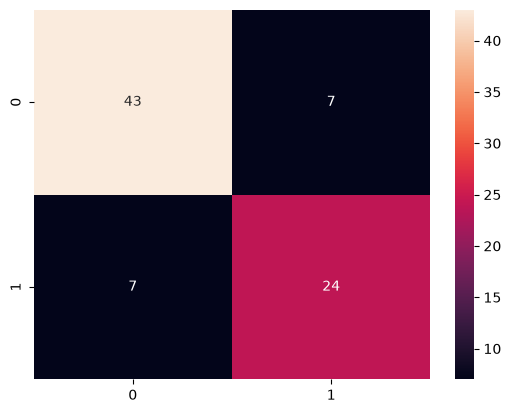

In [100]:
# see the confusion matrix
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='g')

In [101]:
# The AUC score is a super sensitive metric
# you often get low scores, even 0.5

# in binary logistic regression, AUC values are often interpreted as follows:
# A binary classifier is useful only when it achieves ROC-AUC score greater than 0.5 and as near to 1 as possible. 
# If a classifier yields a score less than 0.5, it simply means that the model is performing worse 
# than a random classifier, and therefore is useless.

# In multinomial logistic regression , AUC values are often interpreted as follows: 
# 0.5-0.6 (failed)
# 0.6-0.7 (worthless)
# 0.7-0.8 (poor)
# 0.8-0.9 (good)
# > 0.9 (excellent)

# basically 0.5 means you could get the same result with just random guessing
roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

0.8987096774193548

### Final step: using the model in practice

In [102]:
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='str')

In [103]:
# usually for the GUI application, we save the model-object / variable 
# into a file (by using joblib-module)
# and in the GUI application => we load the save model from the file
# and use the model just like here below

# let's create a Python -dictionary, containing our test values
# THE VARIABLE NAMES HAVE TO MATCH WITH THE ORIGINAL DATASET

# in this dataset:
# 0 => Female
# 1 => Male
tester_row = {
    'Age': 33, 
    'Sex': 0, 
    'Chest pain type': 4, 
    'BP': 120, 
    'Cholesterol': 500, 
    'FBS over 120': 0,
    'EKG results': 1, 
    'Max HR': 140, 
    'Exercise angina': 1, 
    'ST depression': 1,
    'Slope of ST': 2, 
    'Number of vessels fluro': 3, 
    'Thallium': 7
}

# convert to pandas format
tester_row = pd.DataFrame([tester_row])

# SINCE WE SCALED our support variables earlier
# WE HAVE TO DO IT HERE AS WELL
tester_row = sc.transform(tester_row)

In [104]:
print("All probabilities by category:")
print(model.predict_proba(tester_row))
print()

# change these based on your original data / target variable
labels = ["No", "Yes"]

print("Does this person have the heart disease (Yes/No):")
result = labels[model.predict(tester_row)[0]]
print(result)
print("----------------------")

All probabilities by category:
[[0.00207417 0.99792583]]

Does this person have the heart disease (Yes/No):
Yes
----------------------


In [105]:
# most variables correlate with the target variable
# df.corr()